In [18]:
import os

def load_agent_positions(save_dir: str, num_files: int):
    """Load agent positions saved as `{index}_agent_positions.npz`.

    Returns a dict with keys `agent_xy` (concatenated numpy array) and `update_idx`.
    """
    import numpy as _np
    import re

    files = []
    for name in os.listdir(save_dir):
        match = re.match(r"^(\d+)_agent_positions\.npz$", name)
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(f"No '*_agent_positions.npz' files found in {save_dir}")

    files.sort(key=lambda x: x[0])
    candidates = files[:num_files] if num_files is not None else files

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    agent_xy_list = []
    update_indices = []

    for selected_idx, fname in candidates:
        with _np.load(fname) as data:
            agent_xy_list.append(data["agent_xy"].copy())
            update_indices.append(int(data["update_idx"]) if "update_idx" in data else selected_idx)

    agent_xy = _np.concatenate(agent_xy_list, axis=0)

    return {"agent_xy": agent_xy, "update_idx": update_indices}

In [22]:
save_dir = "/network/scratch/f/faisal.mohamed/purejaxrl/states/maestro_451994"
index = 100000
output = load_agent_positions(save_dir, index)
xy = output["agent_xy"]

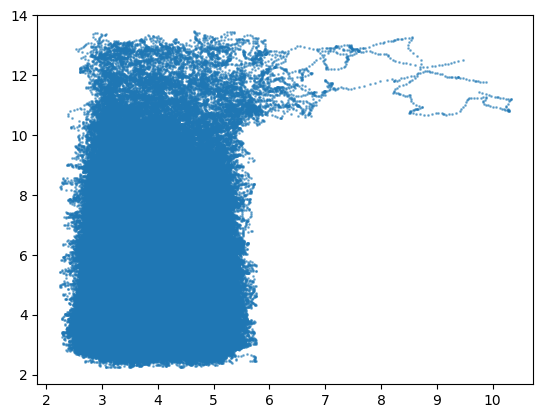

In [23]:
import matplotlib.pyplot as plt
plt.scatter(xy[:, 0], xy[:, 1], s=1, alpha=0.5)
# plt.title(f"Agent positions at update index {output['update_idx']}")